# Dispersion-Assisted Phase Recovery — A Visual Gallery

Synthetic two-plane data for the carrier-less receiver, rendered five ways. The hidden complex field
$x(t)=A(t)e^{i\phi(t)}$ holds its information in the **phase** — invisible to a power detector — so the
art here is making that phase *visible*: as colour, as a 3-D spiral, as a stretch in the
time-dispersion plane. Civilian optical-metrology data; exported to `data/` and `figures/` for the
repo.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from dgs import dispersion_gs_prototype as dg

root = pathlib.Path.cwd().parent
(root / "data").mkdir(exist_ok=True); (root / "figures").mkdir(exist_ok=True)

data = dg.make_measurements(N=2048, D=6000.0, snr_db=30.0, seed=7)
t, x, A, phi = data["t"], data["x"], data["A"], data["phi"]
dg.export_csv(root / "data" / "dispersion_gs_synthetic.csv", data)
dg.export_npz(root / "data" / "dispersion_gs_synthetic.npz", data)
print("exported data/dispersion_gs_synthetic.{csv,npz}")

exported data/dispersion_gs_synthetic.{csv,npz}


## 1 — The measurements $I_1$ and $I_2$

What the detectors actually see: intensity before and after dispersion. The phase is hidden in here.

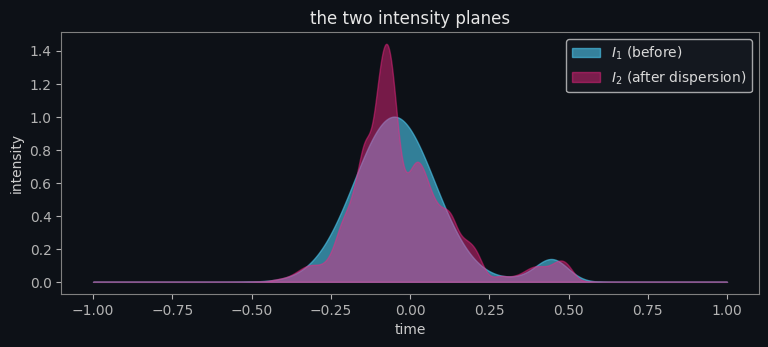

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.fill_between(t, 0, data["I1_clean"], color="#4cc9f0", alpha=0.6, label="$I_1$ (before)")
ax.fill_between(t, 0, data["I2_clean"], color="#f72585", alpha=0.45, label="$I_2$ (after dispersion)")
ax.set_xlabel("time"); ax.set_ylabel("intensity"); ax.legend()
ax.set_title("the two intensity planes"); ax.set_facecolor("#0d1117"); fig.patch.set_facecolor("#0d1117")
for s in ax.spines.values(): s.set_color("0.5")
ax.tick_params(colors="0.7"); ax.xaxis.label.set_color("0.8"); ax.yaxis.label.set_color("0.8")
ax.title.set_color("0.9"); ax.legend(labelcolor="0.85", facecolor="#161b22")
fig.savefig(root / "figures" / "gallery_I1_I2.png", dpi=120, facecolor=fig.get_facecolor())
plt.show()

## 2 — Phase made visible (domain colouring)

The amplitude envelope, filled with a **cyclic colour wheel of the phase**. Now the chirp and ripple
that a power detector throws away are right there as sweeping colour.

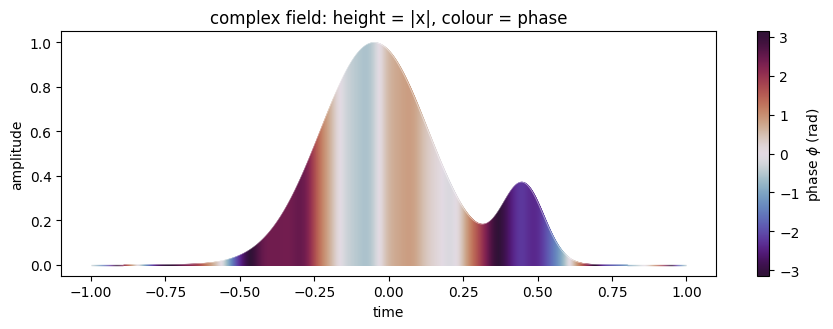

In [3]:
from matplotlib.colors import Normalize
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(9, 3.4))
norm = Normalize(-np.pi, np.pi)
colors = cm.twilight_shifted(norm(np.mod(phi + np.pi, 2*np.pi) - np.pi))
for i in range(len(t)-1):
    ax.fill_between(t[i:i+2], 0, A[i:i+2], color=colors[i])
sm = cm.ScalarMappable(norm=norm, cmap="twilight_shifted")
cb = fig.colorbar(sm, ax=ax, label="phase $\\phi$ (rad)")
ax.plot(t, A, color="w", lw=0.6, alpha=0.5)
ax.set_xlabel("time"); ax.set_ylabel("amplitude"); ax.set_title("complex field: height = |x|, colour = phase")
plt.tight_layout(); fig.savefig(root / "figures" / "gallery_phase_color.png", dpi=120); plt.show()

## 3 — The dispersion stretch

$|{\rm disperse}(x,D)|^2$ as the dispersion $D$ ramps up: the pulse fans out and reshapes — the
time-stretch transform, and the source of the diversity that makes phase recovery possible.

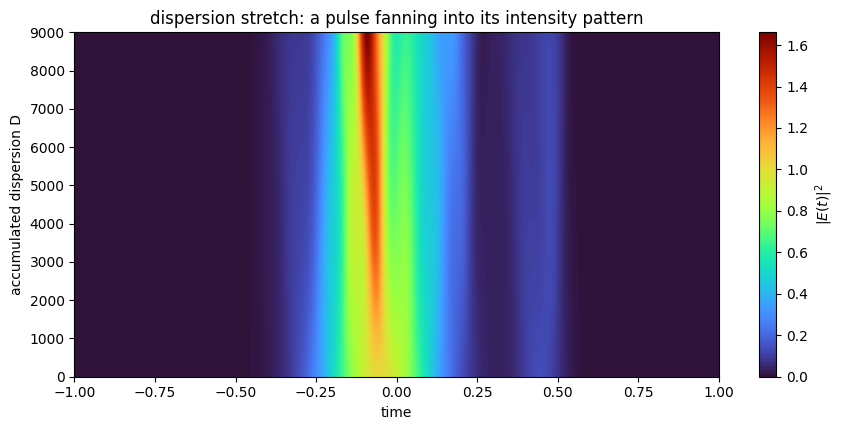

In [4]:
Dgrid = np.linspace(0, 9000, 240)
stretch = np.array([np.abs(dg.disperse(x, D))**2 for D in Dgrid])
fig, ax = plt.subplots(figsize=(9, 4.4))
im = ax.imshow(stretch, aspect="auto", origin="lower", cmap="turbo",
               extent=[t[0], t[-1], 0, Dgrid[-1]])
fig.colorbar(im, ax=ax, label="$|E(t)|^2$")
ax.set_xlabel("time"); ax.set_ylabel("accumulated dispersion D")
ax.set_title("dispersion stretch: a pulse fanning into its intensity pattern")
plt.tight_layout(); fig.savefig(root / "figures" / "gallery_stretch.png", dpi=120); plt.show()

## 4 — The field as a 3-D spiral

Plot $(t,\ \mathrm{Re}\,x,\ \mathrm{Im}\,x)$: the complex field is a ribbon that spirals — fast where
the instantaneous frequency is high (the chirp), its radius the amplitude. The same helix geometry as
the DNA / FM notebooks, now traced by an optical field.

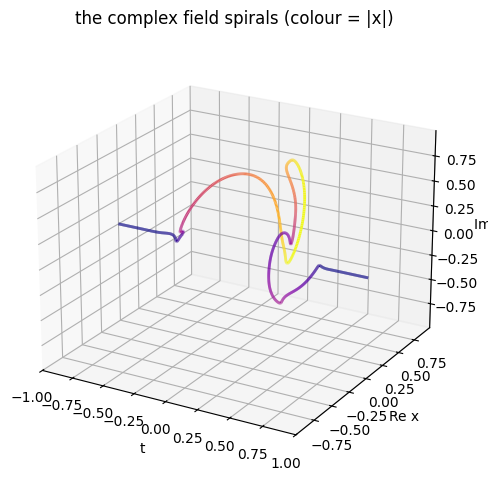

In [5]:
fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection="3d")
pts = np.array([t, x.real, x.imag]).T.reshape(-1, 1, 3)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = __import__("mpl_toolkits.mplot3d.art3d", fromlist=["Line3DCollection"]).Line3DCollection(
    segs, cmap="plasma", array=A[:-1], linewidth=2)
ax.add_collection3d(lc)
ax.set_xlim(t.min(), t.max()); ax.set_ylim(-A.max(), A.max()); ax.set_zlim(-A.max(), A.max())
ax.set_xlabel("t"); ax.set_ylabel("Re x"); ax.set_zlabel("Im x")
ax.set_title("the complex field spirals (colour = |x|)"); ax.view_init(22, -60)
plt.tight_layout(); fig.savefig(root / "figures" / "gallery_helix.png", dpi=120); plt.show()

## 5 — The I-Q trajectory

Looking down the time axis: $\mathrm{Re}\,x$ vs $\mathrm{Im}\,x$, the curve coloured by time. The
loops are the phase winding; the excursion is the amplitude — a comet tracing the field through the
complex plane.

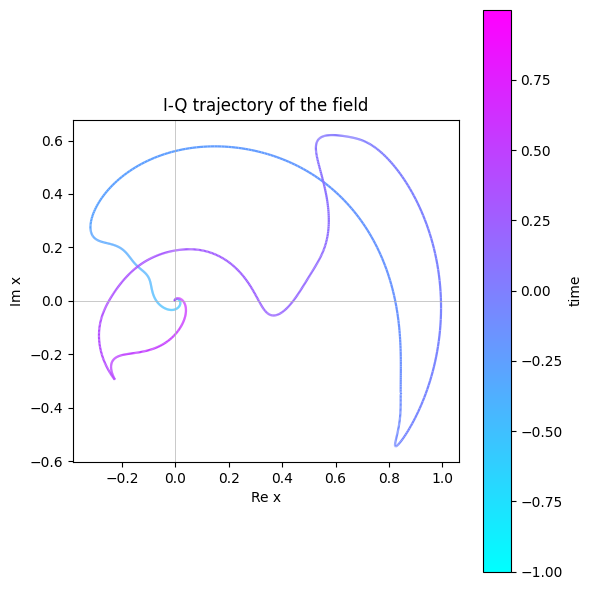

saved 5 figures to figures/gallery_*.png


In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
pts2 = np.array([x.real, x.imag]).T.reshape(-1, 1, 2)
segs2 = np.concatenate([pts2[:-1], pts2[1:]], axis=1)
lc2 = LineCollection(segs2, cmap="cool", array=t[:-1], linewidth=1.6)
ax.add_collection(lc2); ax.autoscale(); ax.set_aspect("equal")
ax.axhline(0, color="0.7", lw=0.5); ax.axvline(0, color="0.7", lw=0.5)
fig.colorbar(lc2, ax=ax, label="time")
ax.set_xlabel("Re x"); ax.set_ylabel("Im x"); ax.set_title("I-Q trajectory of the field")
plt.tight_layout(); fig.savefig(root / "figures" / "gallery_iq.png", dpi=120); plt.show()
print("saved 5 figures to figures/gallery_*.png")

## Files

- `data/dispersion_gs_synthetic.{csv,npz}` — the synthetic two-plane dataset (with hidden truth).
- `figures/gallery_*.png` — the five renders above.

Every panel is the *same* field; the gallery is five lenses on the one quantity — the optical phase —
that this whole project exists to recover.